# Customer RFM Segmentation & Clustering Analysis

## Business Problem
A retail business wants to understand its customer base better.
By segmenting customers using RFM (Recency, Frequency, Monetary) 
analysis and K-Means clustering, we can:
- Identify high-value customers worth retaining
- Detect churned customers who need re-engagement
- Prioritise marketing spend more effectively
- Flag unusual transaction patterns

## Approach
1. Generate realistic synthetic transaction data
2. Clean and validate the data
3. Calculate RFM scores per customer
4. Apply K-Means clustering
5. Validate clusters against known customer tiers
6. Visualise findings and export for Power BI

## Tools
Python, Pandas, Scikit-learn, Matplotlib, Seaborn

In [2]:
# ── IMPORTS ────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from datetime import datetime, timedelta
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score
from collections import Counter

# Display settings
pd.set_option("display.float_format", "{:.2f}".format)
pd.set_option("display.max_columns", 20)
plt.style.use("seaborn-v0_8")
sns.set_palette("husl")

print("Libraries loaded successfully")

Libraries loaded successfully


## Section 1 — Data Generation
Generating 55,000 synthetic retail transactions across 8,000 customers.
Customers are pre-assigned to behavioural tiers which we will use 
later to validate our clustering results.

In [3]:
def generate_transactions(n_records=55000, seed=42):
    np.random.seed(seed)

    n_customers = 8000
    customer_ids = [f"CUST_{i:05d}" for i in range(1, n_customers + 1)]

    tiers = ["high_value", "mid_value", "low_value", "churned"]
    probs = [0.10, 0.25, 0.40, 0.25]
    customer_tiers = dict(
        zip(customer_ids, np.random.choice(tiers, n_customers, p=probs))
    )

    # (min_days_ago, max_days_ago, mean_amount, std_amount)
    tier_params = {
        "high_value": (1,  60,  250, 80),
        "mid_value":  (1,  180, 100, 40),
        "low_value":  (30, 270, 40,  20),
        "churned":    (270, 365, 30, 15),
    }

    # Weighted selection — frequency differs by tier
    frequency_weights = {
        "high_value": 4.0,
        "mid_value":  2.0,
        "low_value":  1.0,
        "churned":    0.3
    }
    weights = np.array([
        frequency_weights[customer_tiers[c]] for c in customer_ids
    ])
    weights = weights / weights.sum()

    snapshot_date = datetime(2024, 12, 31)

    # Pre-generate unique transaction IDs
    transaction_ids = [f"TXN_{i:06d}" for i in range(1, n_records + 1)]
    np.random.shuffle(transaction_ids)

    records = []

    for idx in range(n_records):
        cust_id = np.random.choice(customer_ids, p=weights)
        tier = customer_tiers[cust_id]
        min_days, max_days, mu, sigma = tier_params[tier]

        days_ago = np.random.randint(min_days, max_days + 1)
        date = snapshot_date - timedelta(days=days_ago)

        amount = round(np.random.lognormal(np.log(mu), 0.5), 2)
        amount = max(0.50, amount)

        records.append({
            "transaction_id": transaction_ids[idx],
            "customer_id": cust_id,
            "transaction_date": date,
            "amount": amount,
            "product_category": np.random.choice(
                ["Electronics", "Apparel", "Home", "Beauty", "Sports"]
            ),
            "channel": np.random.choice(["Web", "Mobile", "In-Store"]),
            "region": np.random.choice(
                ["North", "South", "East", "West", "London"],
                p=[0.15, 0.20, 0.15, 0.15, 0.35]
            )
        })

    df = pd.DataFrame(records)

    # Intentional data quality issues
    n_null = int(n_records * 0.01)
    null_idx = np.random.choice(df.index, n_null, replace=False)
    df.loc[null_idx[:n_null//2], "amount"] = np.nan
    df.loc[null_idx[n_null//2:], "customer_id"] = np.nan

    n_neg = int(n_records * 0.005)
    neg_idx = np.random.choice(df.index, n_neg, replace=False)
    df.loc[neg_idx, "amount"] = -abs(df.loc[neg_idx, "amount"])

    # Ground truth customer table
    customer_df = pd.DataFrame({
        "customer_id": customer_ids,
        "true_tier": [customer_tiers[c] for c in customer_ids]
    })

    print(f"Generated {len(df):,} transactions")
    print(f"Customers: {n_customers:,}")
    print(f"Date range: {df['transaction_date'].min().date()} "
          f"to {df['transaction_date'].max().date()}")
    print(f"\nTier distribution:")
    print(customer_df["true_tier"].value_counts())

    return df, customer_df


# Run it
transactions, customers = generate_transactions()

Generated 55,000 transactions
Customers: 8,000
Date range: 2024-01-01 to 2024-12-30

Tier distribution:
true_tier
low_value     3196
mid_value     2008
churned       1957
high_value     839
Name: count, dtype: int64


### Quick look at raw data

In [5]:
print("SHAPE:", transactions.shape)
print("\nFIRST 5 ROWS:")
transactions.head()

SHAPE: (55000, 7)

FIRST 5 ROWS:


,transaction_id,customer_id,transaction_date,amount,product_category,channel,region
0,TXN_037362,CUST_07976,2024-07-04,261.42,Electronics,Web,London
1,TXN_032398,CUST_05409,2024-11-08,96.94,Apparel,Web,London
2,TXN_013400,CUST_05152,2024-09-20,152.38,Electronics,Mobile,West
3,TXN_004564,CUST_06649,2024-04-21,33.58,Sports,Web,London
4,TXN_015375,CUST_03773,2024-10-21,64.17,Electronics,In-Store,London


## Section 2 — Data Cleaning

Before calculating RFM we need to:
1. Understand what data quality issues exist
2. Handle null values
3. Remove invalid transactions (negative amounts)
4. Remove duplicate transaction IDs
5. Fix data types
6. Document every decision made

**Every cleaning decision is a business decision — 
we document why, not just what.**

### 2.1 — Data Quality Assessment
First understand the problems before fixing them.

In [49]:
def assess_data_quality(df):
    print("-" * 50)
    print("DATA QUALITY REPORT")
    print("-" * 50)
    
    # Shape
    print(f"\nTotal Records  : {len(df):,}")      #{value:format}
    print(f"Total Columns  : {df.shape[1]}")
    
    # Null values
    print("\nNULL VALUES:")
    nulls = df.isnull().sum()
    null_pct = (df.isnull().sum() / len(df) * 100).round(2)
    null_report = pd.DataFrame({
        "null_count": nulls,
        "null_pct": null_pct
    })
    print(null_report[null_report["null_count"] > 0])
    
    # Negative amounts
    neg_amounts = df[df["amount"] < 0]
    print(f"\nNEGATIVE AMOUNTS: {len(neg_amounts):,} "
          f"({len(neg_amounts)/len(df)*100:.2f}%)")
    
    # Duplicate transaction IDs
    dup_txn = df.duplicated(subset=["transaction_id"]).sum()
    print(f"DUPLICATE TXN IDs: {dup_txn:,}")
    
    # Duplicate customer+date+amount (suspicious duplicates)
    dup_records = df.duplicated(
        subset=["customer_id", "transaction_date", "amount"]
    ).sum()
    print(f"SUSPICIOUS DUPLICATES: {dup_records:,}")
    
    # Date range
    print(f"\nDATE RANGE: {df['transaction_date'].min().date()} "
          f"to {df['transaction_date'].max().date()}")
    
    # Amount stats
    print(f"\nAMOUNT STATS (excluding nulls):")
    print(df["amount"].describe())
    
    print("\n" + "-" * 50)

assess_data_quality(transactions)

--------------------------------------------------
DATA QUALITY REPORT
--------------------------------------------------

Total Records  : 55,000
Total Columns  : 7

NULL VALUES:
             null_count  null_pct
customer_id         275      0.50
amount              275      0.50

NEGATIVE AMOUNTS: 275 (0.50%)
DUPLICATE TXN IDs: 0
SUSPICIOUS DUPLICATES: 0

DATE RANGE: 2024-01-01 to 2024-12-30

AMOUNT STATS (excluding nulls):
count   54725.00
mean      139.75
std       134.69
min      -652.51
25%        47.16
50%        94.74
75%       189.71
max      1761.62
Name: amount, dtype: float64

--------------------------------------------------


### 2.2 — Cleaning Steps

| Issue | Decision | Reason |
|---|---|---|
| Null customer_id | Remove row | Cannot assign to a customer |
| Null amount | Remove row | Cannot calculate monetary value |
| Negative amount | Remove row | Invalid transaction — not a refund column |
| Duplicate TXN IDs | Keep first | System error — same transaction logged twice |
| Data types | Fix dates and amounts | Required for calculations |

In [50]:
def clean_transactions(df):
    original_count = len(df)
    cleaning_log = []
    
    df_clean = df.copy()
    
    # Step 1 — Fix data types first
    df_clean["transaction_date"] = pd.to_datetime(
        df_clean["transaction_date"]
    )
    df_clean["amount"] = pd.to_numeric(
        df_clean["amount"], errors="coerce"
    )
    
    # Step 2 — Remove null customer_id
    before = len(df_clean)
    df_clean = df_clean.dropna(subset=["customer_id"])
    removed = before - len(df_clean)
    cleaning_log.append({
        "step": "Remove null customer_id",
        "rows_removed": removed,
        "reason": "Cannot assign transaction to customer"
    })
    
    # Step 3 — Remove null amount
    before = len(df_clean)
    df_clean = df_clean.dropna(subset=["amount"])
    removed = before - len(df_clean)
    cleaning_log.append({
        "step": "Remove null amount",
        "rows_removed": removed,
        "reason": "Cannot calculate monetary value"
    })
    
    # Step 4 — Remove negative amounts
    before = len(df_clean)
    df_clean = df_clean[df_clean["amount"] > 0]
    removed = before - len(df_clean)
    cleaning_log.append({
        "step": "Remove negative amounts",
        "rows_removed": removed,
        "reason": "Invalid transactions — no refund handling in scope"
    })
    
    # Step 5 — Remove duplicate transaction IDs
    before = len(df_clean)
    df_clean = df_clean.drop_duplicates(subset=["transaction_id"])
    removed = before - len(df_clean)
    cleaning_log.append({
        "step": "Remove duplicate transaction IDs",
        "rows_removed": removed,
        "reason": "Same transaction logged twice — keep first occurrence"
    })
    
    # Step 6 — Reset index
    df_clean = df_clean.reset_index(drop=True)
    
    # Print cleaning summary
    print("-" * 50)
    print("CLEANING SUMMARY")
    print("-" * 50)
    
    log_df = pd.DataFrame(cleaning_log)
    print(log_df.to_string(index=False))
    
    print(f"\nOriginal records : {original_count:,}")
    print(f"Clean records    : {len(df_clean):,}")
    print(f"Records removed  : {original_count - len(df_clean):,} "
          f"({(original_count - len(df_clean))/original_count*100:.2f}%)")
    print("-" * 50)
    
    return df_clean


df_clean = clean_transactions(transactions)

--------------------------------------------------
CLEANING SUMMARY
--------------------------------------------------
                            step  rows_removed                                                reason
         Remove null customer_id           275                 Cannot assign transaction to customer
              Remove null amount           275                       Cannot calculate monetary value
         Remove negative amounts           273    Invalid transactions — no refund handling in scope
Remove duplicate transaction IDs             0 Same transaction logged twice — keep first occurrence

Original records : 55,000
Clean records    : 54,177
Records removed  : 823 (1.50%)
--------------------------------------------------


### 2.3 — Verify Cleaning Worked

In [9]:
# Quick verification checks
print("VERIFICATION CHECKS:")
print(f"Null amounts     : {df_clean['amount'].isnull().sum()}")
print(f"Null customer_id : {df_clean['customer_id'].isnull().sum()}")
print(f"Negative amounts : {(df_clean['amount'] < 0).sum()}")
print(f"Duplicate TXN IDs: "
      f"{df_clean.duplicated(subset=['transaction_id']).sum()}")
print(f"\nAll checks passed!" 
      if df_clean['amount'].isnull().sum() == 0 
      and df_clean['customer_id'].isnull().sum() == 0
      and (df_clean['amount'] < 0).sum() == 0
      else "Issues remain — check above")

print(f"\nClean data shape: {df_clean.shape}")
print(f"\nAmount stats after cleaning:")
print(df_clean["amount"].describe())

VERIFICATION CHECKS:
Null amounts     : 0
Null customer_id : 0
Negative amounts : 0
Duplicate TXN IDs: 0

All checks passed!

Clean data shape: (54177, 7)

Amount stats after cleaning:
count   54177.00
mean      141.15
std       133.36
min         5.52
25%        47.68
50%        95.37
75%       190.37
max      1761.62
Name: amount, dtype: float64


### 2.4 — Exploratory Data Analysis
Understanding the clean data before RFM calculation.

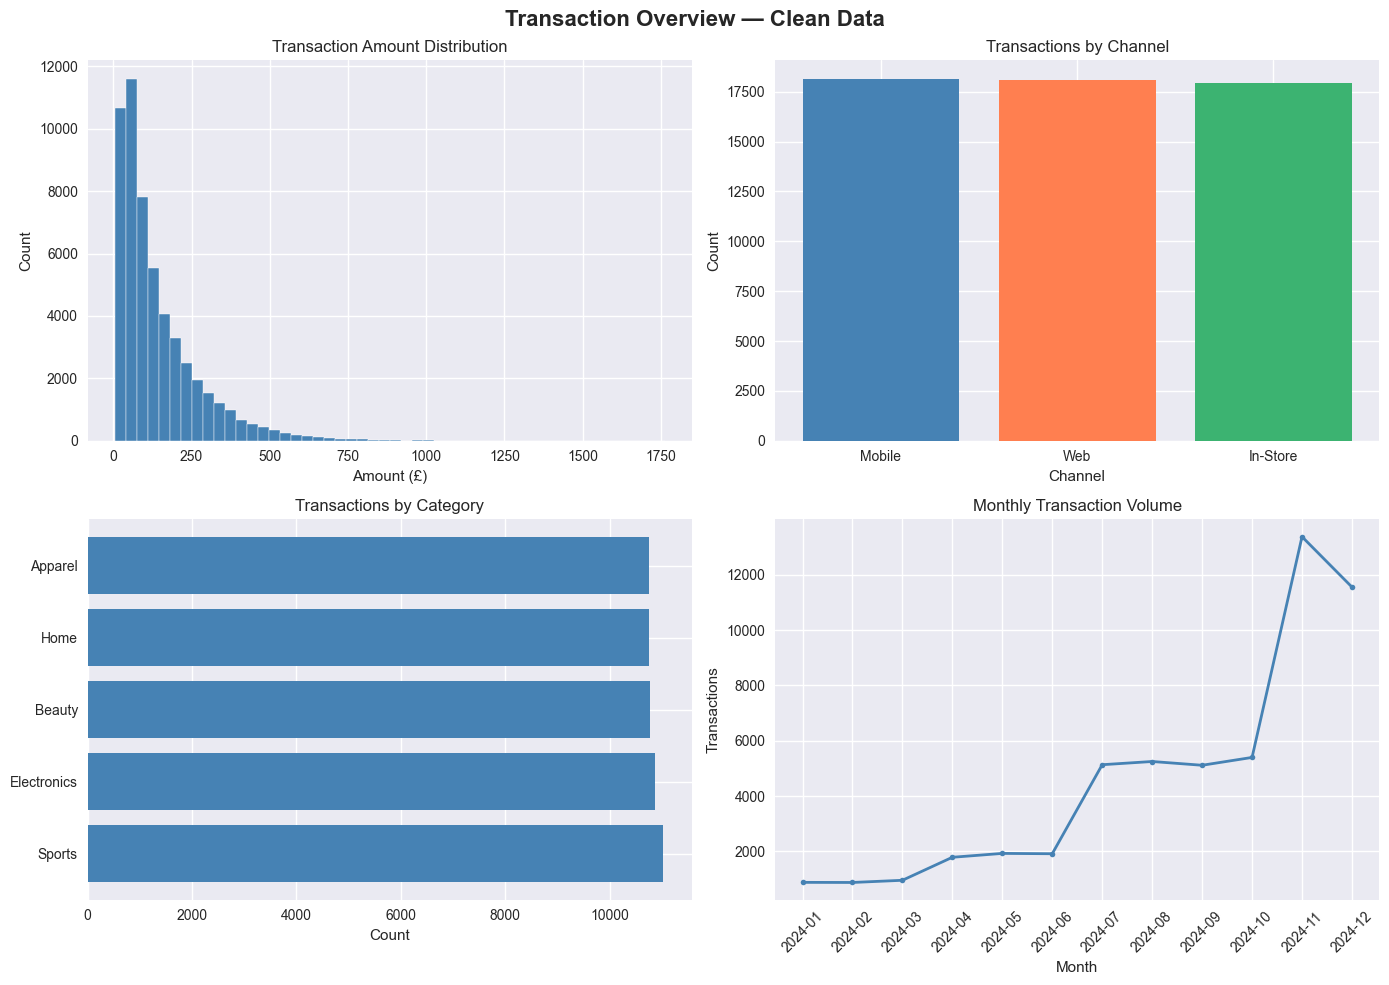

Chart saved to outputs/eda_overview.png


In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Transaction Overview — Clean Data", 
             fontsize=16, fontweight="bold")

# Plot 1 — Transaction amount distribution
axes[0, 0].hist(df_clean["amount"], bins=50, 
                color="steelblue", edgecolor="white")
axes[0, 0].set_title("Transaction Amount Distribution")
axes[0, 0].set_xlabel("Amount (£)")
axes[0, 0].set_ylabel("Count")

# Plot 2 — Transactions by channel
channel_counts = df_clean["channel"].value_counts()
axes[0, 1].bar(channel_counts.index, channel_counts.values,
               color=["steelblue", "coral", "mediumseagreen"])
axes[0, 1].set_title("Transactions by Channel")
axes[0, 1].set_xlabel("Channel")
axes[0, 1].set_ylabel("Count")

# Plot 3 — Transactions by product category
cat_counts = df_clean["product_category"].value_counts()
axes[1, 0].barh(cat_counts.index, cat_counts.values,
                color="steelblue")
axes[1, 0].set_title("Transactions by Category")
axes[1, 0].set_xlabel("Count")

# Plot 4 — Monthly transaction volume
df_clean["month"] = df_clean["transaction_date"].dt.to_period("M")
monthly = df_clean.groupby("month").size()
axes[1, 1].plot(monthly.index.astype(str), 
                monthly.values, 
                color="steelblue", 
                linewidth=2,
                marker="o",
                markersize=4)
axes[1, 1].set_title("Monthly Transaction Volume")
axes[1, 1].set_xlabel("Month")
axes[1, 1].set_ylabel("Transactions")
axes[1, 1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig("outputs/eda_overview.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved to outputs/eda_overview.png")

## Section 3 — RFM Calculation

RFM is a proven customer segmentation framework used in retail,
banking, and marketing analytics.

| Metric | Definition | Business Meaning |
|---|---|---|
| Recency | Days since last purchase | Lower = more engaged |
| Frequency | Number of transactions | Higher = more loyal |
| Monetary | Total amount spent | Higher = more valuable |

**Snapshot date: 2024-12-31**
We calculate recency relative to this date.
A customer who bought yesterday has recency = 1.
A customer who bought 300 days ago has recency = 300.

### 3.1 — Calculate Raw RFM Values

In [12]:
def calculate_rfm(df, snapshot_date=datetime(2024, 12, 31)):
    
    print("Calculating RFM values...")
    
    rfm = df.groupby("customer_id").agg(
        recency   = ("transaction_date", 
                     lambda x: (snapshot_date - x.max()).days),
        frequency = ("transaction_id", "count"),
        monetary  = ("amount", "sum")
    ).reset_index()
    
    rfm["monetary"] = rfm["monetary"].round(2)
    
    print(f"Customers in RFM table: {len(rfm):,}")
    print(f"\nRFM Summary:")
    print(rfm[["recency", "frequency", "monetary"]].describe().round(2))
    
    return rfm


rfm = calculate_rfm(df_clean)

Calculating RFM values...
Customers in RFM table: 7,546

RFM Summary:
       recency  frequency  monetary
count  7546.00    7546.00   7546.00
mean    100.25       7.18   1013.39
std     112.70       5.83   1731.06
min       1.00       1.00      6.51
25%      15.00       3.00    111.34
50%      50.00       6.00    271.45
75%     136.00      10.00   1053.16
max     365.00      38.00  11242.09


### 3.2 — RFM Scoring

We score each metric from 1 to 5 using quintiles.

**Important — Recency is scored in reverse:**
- Low recency (bought recently) = Score 5 (good)
- High recency (bought long ago) = Score 1 (bad)

**Frequency and Monetary:**
- High value = Score 5 (good)
- Low value = Score 1 (bad)

In [14]:
def score_rfm(rfm):
    
    rfm_scored = rfm.copy()
    
    # Recency — lower is better so reverse the scoring
    rfm_scored["r_score"] = pd.qcut(
        rfm_scored["recency"],
        q=5,
        labels=[5, 4, 3, 2, 1]  # Reversed
    ).astype(int)
    
    # Frequency — higher is better
    rfm_scored["f_score"] = pd.qcut(
        rfm_scored["frequency"].rank(method="first"),
        q=5,
        labels=[1, 2, 3, 4, 5]
    ).astype(int)
    
    # Monetary — higher is better
    rfm_scored["m_score"] = pd.qcut(
        rfm_scored["monetary"].rank(method="first"),
        q=5,
        labels=[1, 2, 3, 4, 5]
    ).astype(int)
    
    # Combined RFM score
    rfm_scored["rfm_score"] = (
        rfm_scored["r_score"].astype(str) +
        rfm_scored["f_score"].astype(str) +
        rfm_scored["m_score"].astype(str)
    )
    
    # Overall score out of 15
    rfm_scored["rfm_total"] = (
        rfm_scored["r_score"] +
        rfm_scored["f_score"] +
        rfm_scored["m_score"]
    )
    
    print("RFM Scoring complete")
    print(f"\nScore distribution (rfm_total):")
    print(rfm_scored["rfm_total"].describe().round(2))
    print(f"\nSample of scored customers:")
    print(rfm_scored.head(10).to_string(index=False))
    
    return rfm_scored


rfm_scored = score_rfm(rfm)

RFM Scoring complete

Score distribution (rfm_total):
count   7546.00
mean       9.01
std        4.06
min        3.00
25%        6.00
50%        9.00
75%       13.00
max       15.00
Name: rfm_total, dtype: float64

Sample of scored customers:
customer_id  recency  frequency  monetary  r_score  f_score  m_score rfm_score  rfm_total
 CUST_00001      226          5    167.34        2        3        2       232          7
 CUST_00003       85          5    234.14        2        3        3       233          8
 CUST_00004       76          7    257.78        2        3        3       233          8
 CUST_00005       33         10   1490.08        4        4        5       445         13
 CUST_00006       13          9    961.69        4        4        4       444         12
 CUST_00007        1         15   5018.81        5        5        5       555         15
 CUST_00008      300          2     55.72        1        1        1       111          3
 CUST_00009       67          1     3

### 3.3 — Assign Segment Labels
Mapping RFM scores to business-meaningful segment names.

In [19]:
def assign_segments(rfm_scored):
    
    def label_segment(row):
        r = row["r_score"]
        f = row["f_score"]
        m = row["m_score"]
        total = row["rfm_total"]
    
    # Tightened thresholds
        if r == 5 and f >= 4 and m >= 4:        
            return "Champions"
        elif r >= 4 and f >= 4 and m >= 3:
            return "Loyal Customers"
        elif r >= 4 and f <= 2:
            return "New Customers"
        elif r <= 2 and f >= 3 and m >= 3:
            return "At Risk"
        elif r == 1 and f <= 2:                  
            return "Lost"
        elif total >= 10:                        
            return "Potential Loyalists"
        else:
            return "Needs Attention"
    
    rfm_scored["segment"] = rfm_scored.apply(label_segment, axis=1)
    
    print("SEGMENT DISTRIBUTION:")
    print("=" * 40)
    segment_counts = rfm_scored["segment"].value_counts()
    segment_pct = (segment_counts / len(rfm_scored) * 100).round(1)
    
    segment_summary = pd.DataFrame({
        "count": segment_counts,
        "percentage": segment_pct
    })
    print(segment_summary.to_string())
    
    return rfm_scored


rfm_scored = assign_segments(rfm_scored)

SEGMENT DISTRIBUTION:
                     count  percentage
segment                               
Needs Attention       2059       27.30
Champions             1508       20.00
Lost                  1467       19.40
Loyal Customers        937       12.40
Potential Loyalists    890       11.80
At Risk                498        6.60
New Customers          187        2.50


### 3.4 — RFM Visualisations

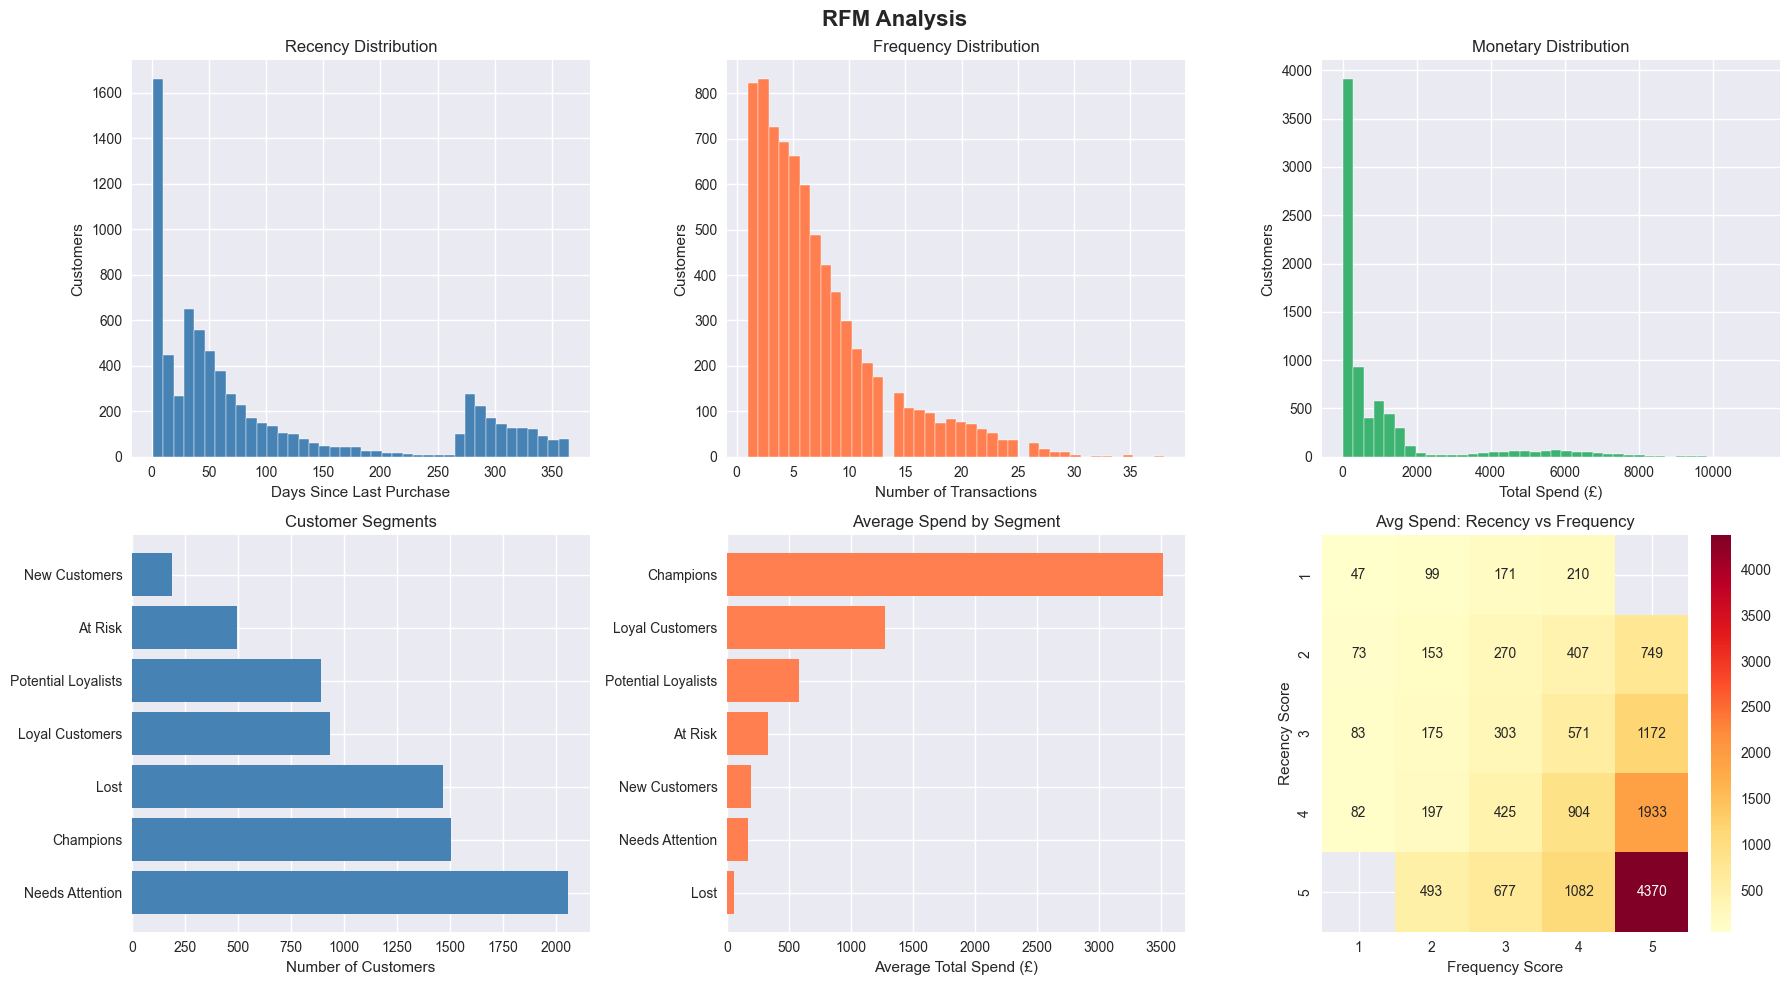

Chart saved to outputs/rfm_analysis.png


In [20]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("RFM Analysis", fontsize=16, fontweight="bold")

# Plot 1 — Recency distribution
axes[0, 0].hist(rfm_scored["recency"], bins=40, 
                color="steelblue", edgecolor="white")
axes[0, 0].set_title("Recency Distribution")
axes[0, 0].set_xlabel("Days Since Last Purchase")
axes[0, 0].set_ylabel("Customers")

# Plot 2 — Frequency distribution
axes[0, 1].hist(rfm_scored["frequency"], bins=40,
                color="coral", edgecolor="white")
axes[0, 1].set_title("Frequency Distribution")
axes[0, 1].set_xlabel("Number of Transactions")
axes[0, 1].set_ylabel("Customers")

# Plot 3 — Monetary distribution
axes[0, 2].hist(rfm_scored["monetary"], bins=40,
                color="mediumseagreen", edgecolor="white")
axes[0, 2].set_title("Monetary Distribution")
axes[0, 2].set_xlabel("Total Spend (£)")
axes[0, 2].set_ylabel("Customers")

# Plot 4 — Segment distribution
segment_counts = rfm_scored["segment"].value_counts()
axes[1, 0].barh(segment_counts.index, 
                segment_counts.values,
                color="steelblue")
axes[1, 0].set_title("Customer Segments")
axes[1, 0].set_xlabel("Number of Customers")

# Plot 5 — Average monetary by segment
avg_monetary = rfm_scored.groupby("segment")["monetary"].mean().sort_values()
axes[1, 1].barh(avg_monetary.index, 
                avg_monetary.values,
                color="coral")
axes[1, 1].set_title("Average Spend by Segment")
axes[1, 1].set_xlabel("Average Total Spend (£)")

# Plot 6 — RFM Score heatmap data
rfm_pivot = rfm_scored.groupby(
    ["r_score", "f_score"]
)["monetary"].mean().unstack()
sns.heatmap(rfm_pivot, ax=axes[1, 2], 
            cmap="YlOrRd",
            fmt=".0f",
            annot=True)
axes[1, 2].set_title("Avg Spend: Recency vs Frequency")
axes[1, 2].set_xlabel("Frequency Score")
axes[1, 2].set_ylabel("Recency Score")

plt.tight_layout()
plt.savefig("outputs/rfm_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved to outputs/rfm_analysis.png")

## Section 4 — K-Means Clustering

RFM scoring gives rule-based segments.
K-Means clustering finds natural groupings in the data
without us defining the rules.

We then compare the two approaches to validate our findings.

**Why both?**
- RFM segments are explainable to business stakeholders
- K-Means finds patterns we might have missed
- Comparing them validates our rule-based logic

### 4.1 — Feature Preparation
K-Means uses distance calculations so we must scale features.
Without scaling, monetary (£0-5000) would dominate 
recency (1-365) and frequency (1-50).

In [21]:
def prepare_clustering_features(rfm_scored):
    
    # Select RFM features only
    features = rfm_scored[["recency", "frequency", "monetary"]].copy()
    
    print("BEFORE SCALING:")
    print(features.describe().round(2))
    
    # Scale features
    scaler = StandardScaler()
    features_scaled = scaler.fit_transform(features)
    features_scaled = pd.DataFrame(
        features_scaled,
        columns=["recency_scaled", 
                 "frequency_scaled", 
                 "monetary_scaled"]
    )
    
    print("\nAFTER SCALING:")
    print(features_scaled.describe().round(2))
    
    return features_scaled, scaler


features_scaled, scaler = prepare_clustering_features(rfm_scored)

BEFORE SCALING:
       recency  frequency  monetary
count  7546.00    7546.00   7546.00
mean    100.25       7.18   1013.39
std     112.70       5.83   1731.06
min       1.00       1.00      6.51
25%      15.00       3.00    111.34
50%      50.00       6.00    271.45
75%     136.00      10.00   1053.16
max     365.00      38.00  11242.09

AFTER SCALING:
       recency_scaled  frequency_scaled  monetary_scaled
count         7546.00           7546.00          7546.00
mean             0.00              0.00             0.00
std              1.00              1.00             1.00
min             -0.88             -1.06            -0.58
25%             -0.76             -0.72            -0.52
50%             -0.45             -0.20            -0.43
75%              0.32              0.48             0.02
max              2.35              5.29             5.91


### 4.2 — Finding Optimal Number of Clusters

We use the Elbow Method:
- Run K-Means for K = 2 to 10
- Plot inertia (sum of squared distances) for each K
- The "elbow" point is where adding more clusters 
  stops meaningfully improving the model

Running K-Means for K = 2 to 10...
  K=2 | Inertia: 11,135
  K=3 | Inertia: 4,071
  K=4 | Inertia: 2,297
  K=5 | Inertia: 1,781
  K=6 | Inertia: 1,399
  K=7 | Inertia: 1,150
  K=8 | Inertia: 998
  K=9 | Inertia: 868
  K=10 | Inertia: 794


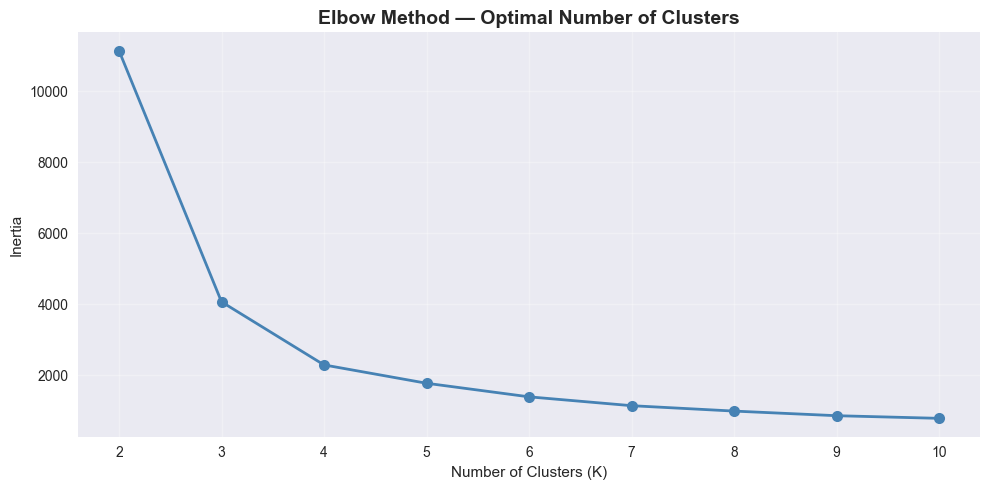

Chart saved to outputs/elbow_curve.png


In [22]:
def find_optimal_k(features_scaled, k_range=range(2, 11)):
    
    inertias = []
    k_values = list(k_range)
    
    print("Running K-Means for K = 2 to 10...")
    
    for k in k_values:
        kmeans = KMeans(
            n_clusters=k,
            random_state=42,
            n_init=10
        )
        kmeans.fit(features_scaled)
        inertias.append(kmeans.inertia_)
        print(f"  K={k} | Inertia: {kmeans.inertia_:,.0f}")
    
    # Plot elbow curve
    fig, ax = plt.subplots(figsize=(10, 5))
    
    ax.plot(k_values, inertias, 
            marker="o", 
            linewidth=2,
            markersize=8,
            color="steelblue")
    
    ax.set_title("Elbow Method — Optimal Number of Clusters",
                 fontsize=14, fontweight="bold")
    ax.set_xlabel("Number of Clusters (K)")
    ax.set_ylabel("Inertia")
    ax.set_xticks(k_values)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig("outputs/elbow_curve.png", 
                dpi=150, bbox_inches="tight")
    plt.show()
    print("Chart saved to outputs/elbow_curve.png")
    
    return inertias


inertias = find_optimal_k(features_scaled)

### 4.3 — Fit K-Means Model

Based on the elbow curve we select K.
We will use K=4 to match our 4 known tiers
(high_value, mid_value, low_value, churned).
This also makes business sense — 4 actionable groups
is more useful than 8 or 10.

In [23]:
def run_kmeans(features_scaled, rfm_scored, n_clusters=4):
    
    print(f"Fitting K-Means with K={n_clusters}...")
    
    kmeans = KMeans(
        n_clusters=n_clusters,
        random_state=42,
        n_init=10
    )
    
    rfm_clustered = rfm_scored.copy()
    rfm_clustered["cluster"] = kmeans.fit_predict(features_scaled)
    
    # Analyse each cluster
    cluster_summary = rfm_clustered.groupby("cluster").agg(
        customer_count = ("customer_id", "count"),
        avg_recency    = ("recency",    "mean"),
        avg_frequency  = ("frequency",  "mean"),
        avg_monetary   = ("monetary",   "mean"),
        total_revenue  = ("monetary",   "sum")
    ).round(2)
    
    cluster_summary["revenue_pct"] = (
        cluster_summary["total_revenue"] /
        cluster_summary["total_revenue"].sum() * 100
    ).round(1)
    
    print("\nCLUSTER SUMMARY:")
    print("=" * 70)
    print(cluster_summary.to_string())
    
    return rfm_clustered, kmeans, cluster_summary


rfm_clustered, kmeans_model, cluster_summary = run_kmeans(
    features_scaled, rfm_scored, n_clusters=4
)

Fitting K-Means with K=4...

CLUSTER SUMMARY:
         customer_count  avg_recency  avg_frequency  avg_monetary  total_revenue  revenue_pct
cluster                                                                                      
0                  1814        17.78          10.91       1270.12     2303998.62        30.10
1                  1650       299.49           1.87         65.10      107419.28         1.40
2                   750         3.44          20.39       5794.69     4346016.34        56.80
3                  3332        68.27           4.80        266.99      889599.79        11.60


### 4.4 — Interpret and Label Clusters

K-Means assigns numbers (0,1,2,3) — not meaningful names.
We interpret each cluster by its RFM characteristics
and assign a business label.

In [24]:
def label_clusters(cluster_summary, rfm_clustered):
    
    # Rank clusters by monetary value to assign labels
    ranked = cluster_summary.sort_values(
        "avg_monetary", ascending=False
    )
    
    print("Clusters ranked by average spend:")
    print(ranked[["avg_recency", "avg_frequency", 
                   "avg_monetary", "revenue_pct"]])
    
    # Assign labels based on RFM profile
    # High monetary + low recency = High Value
    # High recency (days) + low frequency = Churned
    
    cluster_profiles = cluster_summary.copy()
    cluster_profiles["label"] = ""
    
    # Sort by monetary descending
    sorted_by_monetary = cluster_summary["avg_monetary"].sort_values(
        ascending=False
    ).index.tolist()
    
    # Sort by recency descending (highest days = most churned)
    sorted_by_recency = cluster_summary["avg_recency"].sort_values(
        ascending=False
    ).index.tolist()
    
    # Most churned = highest recency days + lowest frequency
    churned_cluster = sorted_by_recency[0]
    
    # High value = highest monetary + lower recency days
    high_value_cluster = sorted_by_monetary[0]
    
    # If they overlap, take second for high value
    if churned_cluster == high_value_cluster:
        high_value_cluster = sorted_by_monetary[1]
    
    # Remaining two clusters = mid and low value
    remaining = [c for c in range(4) 
                 if c not in [churned_cluster, high_value_cluster]]
    
    mid_value_cluster = cluster_summary.loc[
        remaining, "avg_monetary"
    ].idxmax()
    
    low_value_cluster = [
        c for c in remaining if c != mid_value_cluster
    ][0]
    
    # Build label mapping
    label_map = {
        high_value_cluster : "High Value",
        mid_value_cluster  : "Mid Value",
        low_value_cluster  : "Low Value",
        churned_cluster    : "Churned"
    }
    
    print(f"\nCluster Label Mapping:")
    for cluster, label in label_map.items():
        print(f"  Cluster {cluster} → {label}")
    
    rfm_clustered["cluster_label"] = rfm_clustered[
        "cluster"
    ].map(label_map)
    
    return rfm_clustered, label_map


rfm_clustered, label_map = label_clusters(
    cluster_summary, rfm_clustered
)

Clusters ranked by average spend:
         avg_recency  avg_frequency  avg_monetary  revenue_pct
cluster                                                       
2               3.44          20.39       5794.69        56.80
0              17.78          10.91       1270.12        30.10
3              68.27           4.80        266.99        11.60
1             299.49           1.87         65.10         1.40

Cluster Label Mapping:
  Cluster 2 → High Value
  Cluster 0 → Mid Value
  Cluster 3 → Low Value
  Cluster 1 → Churned


### 4.5 — Cluster Visualisations

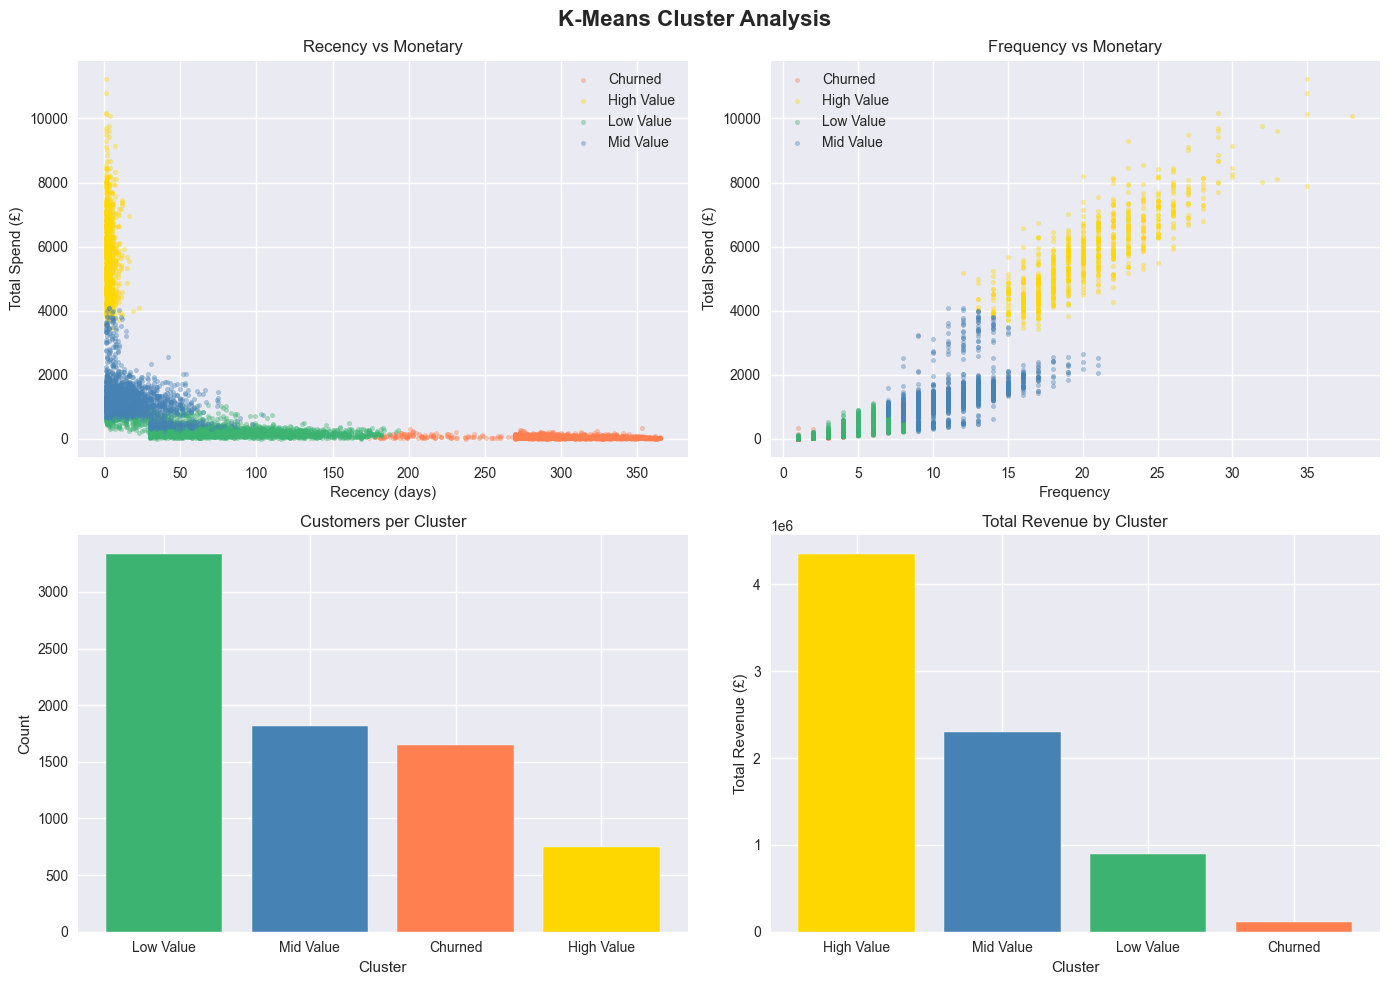

Chart saved to outputs/cluster_analysis.png


In [26]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("K-Means Cluster Analysis", 
             fontsize=16, fontweight="bold")

colors = {
    "High Value" : "gold",
    "Mid Value"  : "steelblue",
    "Low Value"  : "mediumseagreen",
    "Churned"    : "coral"
}

# Plot 1 — Recency vs Monetary scatter
for label, group in rfm_clustered.groupby("cluster_label"):
    axes[0, 0].scatter(
        group["recency"],
        group["monetary"],
        c=colors[label],
        label=label,
        alpha=0.4,
        s=10
    )
axes[0, 0].set_title("Recency vs Monetary")
axes[0, 0].set_xlabel("Recency (days)")
axes[0, 0].set_ylabel("Total Spend (£)")
axes[0, 0].legend()

# Plot 2 — Frequency vs Monetary scatter
for label, group in rfm_clustered.groupby("cluster_label"):
    axes[0, 1].scatter(
        group["frequency"],
        group["monetary"],
        c=colors[label],
        label=label,
        alpha=0.4,
        s=10
    )
axes[0, 1].set_title("Frequency vs Monetary")
axes[0, 1].set_xlabel("Frequency")
axes[0, 1].set_ylabel("Total Spend (£)")
axes[0, 1].legend()

# Plot 3 — Customer count by cluster
cluster_counts = rfm_clustered["cluster_label"].value_counts()
bar_colors = [colors[l] for l in cluster_counts.index]
axes[1, 0].bar(cluster_counts.index, 
               cluster_counts.values,
               color=bar_colors,
               edgecolor="white")
axes[1, 0].set_title("Customers per Cluster")
axes[1, 0].set_xlabel("Cluster")
axes[1, 0].set_ylabel("Count")

# Plot 4 — Revenue concentration by cluster
revenue_by_cluster = rfm_clustered.groupby(
    "cluster_label"
)["monetary"].sum().sort_values(ascending=False)
bar_colors2 = [colors[l] for l in revenue_by_cluster.index]
axes[1, 1].bar(revenue_by_cluster.index,
               revenue_by_cluster.values,
               color=bar_colors2,
               edgecolor="white")
axes[1, 1].set_title("Total Revenue by Cluster")
axes[1, 1].set_xlabel("Cluster")
axes[1, 1].set_ylabel("Total Revenue (£)")

plt.tight_layout()
plt.savefig("outputs/cluster_analysis.png", 
            dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved to outputs/cluster_analysis.png")

## Section 5 — Validation

We have ground truth labels from our data generator.
This lets us answer: **"Did K-Means find the right groups?"**

We use Adjusted Rand Score (ARI):
- ARI = 1.0 → Perfect match
- ARI = 0.0 → Random assignment
- ARI > 0.6 → Strong clustering

### 5.1 — Merge Cluster Results with Ground Truth

In [29]:
def merge_ground_truth(rfm_clustered, customers):
    
    merged = rfm_clustered.merge(
        customers,
        on="customer_id",
        how="left"
    )
    
    print(f"Merged records  : {len(merged):,}")
    print(f"Null true_tiers : {merged['true_tier'].isnull().sum()}")
    print(f"\nGround truth distribution:")
    print(merged["true_tier"].value_counts())
    print(f"\nCluster label distribution:")
    print(merged["cluster_label"].value_counts())
    
    return merged


merged = merge_ground_truth(rfm_clustered, customers)

Merged records  : 7,546
Null true_tiers : 0

Ground truth distribution:
true_tier
low_value     3171
mid_value     2008
churned       1528
high_value     839
Name: count, dtype: int64

Cluster label distribution:
cluster_label
Low Value     3332
Mid Value     1814
Churned       1650
High Value     750
Name: count, dtype: int64


### 5.2 — Confusion Matrix

Rows = True Tier (ground truth)
Columns = Cluster Label (what K-Means found)

A perfect model would show all values on the diagonal.

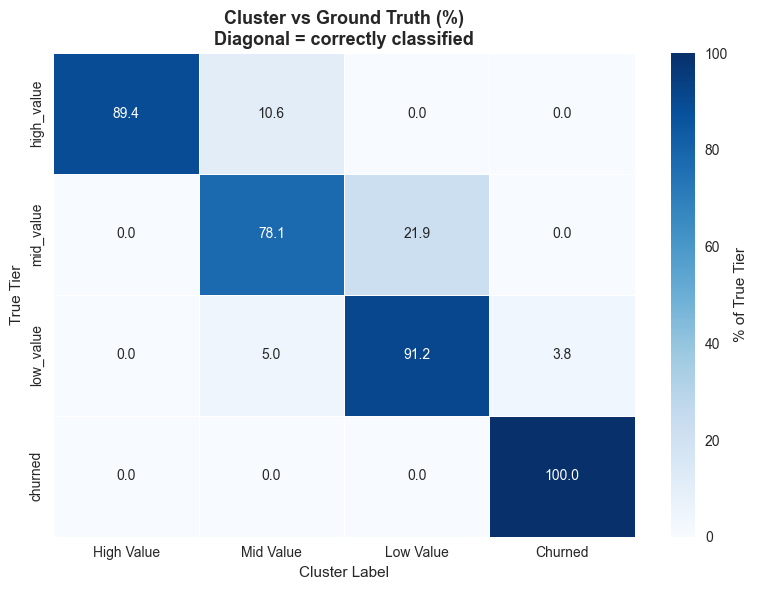

Chart saved to outputs/confusion_matrix.png

Confusion Matrix (% of true tier):
Cluster Label  High Value  Mid Value  Low Value  Churned
True Tier                                               
high_value          89.40      10.60       0.00     0.00
mid_value            0.00      78.10      21.90     0.00
low_value            0.00       5.00      91.20     3.80
churned              0.00       0.00       0.00   100.00


In [31]:
def plot_confusion_matrix(merged):
    
    # Order for readability
    true_order    = ["high_value", "mid_value", 
                     "low_value", "churned"]
    cluster_order = ["High Value", "Mid Value", 
                     "Low Value", "Churned"]
    
    # Build confusion matrix
    confusion = pd.crosstab(
        merged["true_tier"],
        merged["cluster_label"],
        rownames=["True Tier"],
        colnames=["Cluster Label"],
        normalize="index"
    ).reindex(index=true_order, columns=cluster_order) * 100
    
    confusion = confusion.round(1)
    
    # Plot
    fig, ax = plt.subplots(figsize=(8, 6))
    
    sns.heatmap(
        confusion,
        annot=True,
        fmt=".1f",
        cmap="Blues",
        ax=ax,
        linewidths=0.5,
        cbar_kws={"label": "% of True Tier"}
    )
    
    ax.set_title(
        "Cluster vs Ground Truth (%)\n"
        "Diagonal = correctly classified",
        fontsize=13,
        fontweight="bold"
    )
    
    plt.tight_layout()
    plt.savefig("outputs/confusion_matrix.png",
                dpi=150, bbox_inches="tight")
    plt.show()
    print("Chart saved to outputs/confusion_matrix.png")
    
    print("\nConfusion Matrix (% of true tier):")
    print(confusion.to_string())
    
    return confusion


confusion = plot_confusion_matrix(merged)

### 5.3 — Adjusted Rand Index Score

In [33]:
def calculate_ari(merged):
    
    # Map text labels to numbers for ARI calculation
    true_map = {
        "high_value" : 0,
        "mid_value"  : 1,
        "low_value"  : 2,
        "churned"    : 3
    }
    cluster_map = {
        "High Value" : 0,
        "Mid Value"  : 1,
        "Low Value"  : 2,
        "Churned"    : 3
    }
    
    # Drop any nulls before scoring
    valid = merged.dropna(
        subset=["true_tier", "cluster_label"]
    )
    
    true_labels    = valid["true_tier"].map(true_map)
    cluster_labels = valid["cluster_label"].map(cluster_map)
    
    ari = adjusted_rand_score(true_labels, cluster_labels)
    
    print("=" * 45)
    print("ADJUSTED RAND INDEX (ARI) SCORE")
    print("=" * 45)
    print(f"ARI Score : {ari:.4f}")
    print()
    
    if ari >= 0.8:
        print("Result : EXCELLENT — clusters strongly match")
        print("         ground truth tiers")
    elif ari >= 0.6:
        print("Result : GOOD — clusters largely match")
        print("         ground truth tiers")
    elif ari >= 0.4:
        print("Result : MODERATE — partial overlap with")
        print("         ground truth tiers")
    else:
        print("Result : WEAK — clusters do not align well")
        print("         with ground truth tiers")
    
    print()
    print("Interpretation:")
    print("  1.0 = Perfect match")
    print("  0.0 = Random assignment")
    print(f" {ari:.2f} = Our model")
    print("=" * 45)
    
    return ari


ari_score = calculate_ari(merged)

ADJUSTED RAND INDEX (ARI) SCORE
ARI Score : 0.7152

Result : GOOD — clusters largely match
         ground truth tiers

Interpretation:
  1.0 = Perfect match
  0.0 = Random assignment
 0.72 = Our model


### 5.4 — Per Tier Accuracy
How well did K-Means identify each specific tier?

In [36]:
def per_tier_accuracy(merged):
    
    # Map cluster labels to match true tier names
    label_to_tier = {
        "High Value" : "high_value",
        "Mid Value"  : "mid_value",
        "Low Value"  : "low_value",
        "Churned"    : "churned"
    }
    
    merged["cluster_tier"] = merged["cluster_label"].map(
        label_to_tier
    )
    merged["correct"] = (
        merged["true_tier"] == merged["cluster_tier"]
    )
    
    # Overall accuracy
    overall = merged["correct"].mean() * 100
    
    # Per tier accuracy
    tier_accuracy = merged.groupby("true_tier").agg(
        total     = ("correct", "count"),
        correct   = ("correct", "sum")
    )
    tier_accuracy["accuracy_pct"] = (
        tier_accuracy["correct"] / 
        tier_accuracy["total"] * 100
    ).round(1)
    
    print("=" * 45)
    print("CLASSIFICATION ACCURACY")
    print("=" * 45)
    print(f"Overall Accuracy: {overall:.1f}%")
    print()
    print("Per Tier Accuracy:")
    print(tier_accuracy[["total", "correct", 
                          "accuracy_pct"]].to_string())
    print("=" * 45)
    
    return tier_accuracy


tier_accuracy = per_tier_accuracy(merged)

CLASSIFICATION ACCURACY
Overall Accuracy: 89.3%

Per Tier Accuracy:
            total  correct  accuracy_pct
true_tier                               
churned      1528     1528        100.00
high_value    839      750         89.40
low_value    3171     2892         91.20
mid_value    2008     1568         78.10


## Section 6 — Business Insights & Recommendations

The clustering is validated. Now we translate findings
into actionable business recommendations.

Key question: **What should the business DO with this information?**

### 6.1 — Revenue Concentration Analysis
Understanding where revenue actually comes from.

In [37]:
def revenue_concentration_analysis(rfm_clustered):
    
    total_revenue = rfm_clustered["monetary"].sum()
    total_customers = len(rfm_clustered)
    
    summary = rfm_clustered.groupby("cluster_label").agg(
        customers     = ("customer_id",  "count"),
        total_revenue = ("monetary",     "sum"),
        avg_spend     = ("monetary",     "mean"),
        avg_frequency = ("frequency",    "mean"),
        avg_recency   = ("recency",      "mean")
    ).round(2)
    
    summary["customer_pct"] = (
        summary["customers"] / total_customers * 100
    ).round(1)
    
    summary["revenue_pct"] = (
        summary["total_revenue"] / total_revenue * 100
    ).round(1)
    
    # Sort by revenue
    summary = summary.sort_values(
        "total_revenue", ascending=False
    )
    
    print("=" * 65)
    print("REVENUE CONCENTRATION REPORT")
    print("=" * 65)
    print(f"Total Revenue    : £{total_revenue:,.0f}")
    print(f"Total Customers  : {total_customers:,}")
    print()
    
    for segment, row in summary.iterrows():
        print(f"{segment}:")
        print(f"  Customers  : {row['customers']:,} "
              f"({row['customer_pct']}% of base)")
        print(f"  Revenue    : £{row['total_revenue']:,.0f} "
              f"({row['revenue_pct']}% of total)")
        print(f"  Avg Spend  : £{row['avg_spend']:,.0f}")
        print(f"  Avg Orders : {row['avg_frequency']:.1f}")
        print(f"  Avg Recency: {row['avg_recency']:.0f} days")
        print()
    
    # Key insight
    hv = summary.loc["High Value"]
    print("=" * 65)
    print("KEY INSIGHT:")
    print(f"  High Value customers represent only "
          f"{hv['customer_pct']}% of the customer base")
    print(f"  but generate {hv['revenue_pct']}% of total revenue")
    print(f"  — classic Pareto concentration")
    print("=" * 65)
    
    return summary


revenue_summary = revenue_concentration_analysis(rfm_clustered)

REVENUE CONCENTRATION REPORT
Total Revenue    : £7,647,034
Total Customers  : 7,546

High Value:
  Customers  : 750.0 (9.9% of base)
  Revenue    : £4,346,016 (56.8% of total)
  Avg Spend  : £5,795
  Avg Orders : 20.4
  Avg Recency: 3 days

Mid Value:
  Customers  : 1,814.0 (24.0% of base)
  Revenue    : £2,303,999 (30.1% of total)
  Avg Spend  : £1,270
  Avg Orders : 10.9
  Avg Recency: 18 days

Low Value:
  Customers  : 3,332.0 (44.2% of base)
  Revenue    : £889,600 (11.6% of total)
  Avg Spend  : £267
  Avg Orders : 4.8
  Avg Recency: 68 days

Churned:
  Customers  : 1,650.0 (21.9% of base)
  Revenue    : £107,419 (1.4% of total)
  Avg Spend  : £65
  Avg Orders : 1.9
  Avg Recency: 299 days

KEY INSIGHT:
  High Value customers represent only 9.9% of the customer base
  but generate 56.8% of total revenue
  — classic Pareto concentration


### 6.2 — Churn Risk & Revenue at Stake
Quantifying the business cost of churned customers.

In [38]:
def churn_risk_analysis(rfm_clustered):
    
    churned = rfm_clustered[
        rfm_clustered["cluster_label"] == "Churned"
    ]
    at_risk = rfm_clustered[
        rfm_clustered["cluster_label"] == "Low Value"
    ]
    high_value = rfm_clustered[
        rfm_clustered["cluster_label"] == "High Value"
    ]
    
    # Average spend of active customers
    active = rfm_clustered[
        rfm_clustered["cluster_label"] != "Churned"
    ]
    avg_active_spend = active["monetary"].mean()
    
    # Revenue already lost to churn
    lost_revenue = churned["monetary"].sum()
    
    # Potential revenue if churned customers 
    # spent like average active customers
    recovery_potential = (
        len(churned) * avg_active_spend
    ) - lost_revenue
    
    # At risk revenue — low value customers 
    # who might churn next
    at_risk_revenue = at_risk["monetary"].sum()
    
    print("=" * 55)
    print("CHURN RISK ANALYSIS")
    print("=" * 55)
    print(f"\nCHURNED CUSTOMERS:")
    print(f"  Count          : {len(churned):,}")
    print(f"  Avg recency    : "
          f"{churned['recency'].mean():.0f} days")
    print(f"  Revenue to date: £{lost_revenue:,.0f}")
    print(f"  Recovery potential if re-engaged: "
          f"£{recovery_potential:,.0f}")
    
    print(f"\nAT RISK CUSTOMERS (Low Value):")
    print(f"  Count          : {len(at_risk):,}")
    print(f"  Avg recency    : "
          f"{at_risk['recency'].mean():.0f} days")
    print(f"  Revenue at risk: £{at_risk_revenue:,.0f}")
    
    print(f"\nHIGH VALUE CUSTOMERS:")
    print(f"  Count          : {len(high_value):,}")
    print(f"  Avg recency    : "
          f"{high_value['recency'].mean():.0f} days ago")
    print(f"  These customers must be prioritised "
          f"for retention")
    
    print(f"\nRECOMMENDATIONS:")
    print(f"  1. Launch re-engagement campaign "
          f"for {len(churned):,} churned customers")
    print(f"  2. Implement loyalty programme "
          f"for {len(high_value):,} high value customers")
    print(f"  3. Monitor {len(at_risk):,} low value customers"
          f" for early churn signals")
    print("=" * 55)


churn_risk_analysis(rfm_clustered)

CHURN RISK ANALYSIS

CHURNED CUSTOMERS:
  Count          : 1,650
  Avg recency    : 299 days
  Revenue to date: £107,419
  Recovery potential if re-engaged: £2,002,548

AT RISK CUSTOMERS (Low Value):
  Count          : 3,332
  Avg recency    : 68 days
  Revenue at risk: £889,600

HIGH VALUE CUSTOMERS:
  Count          : 750
  Avg recency    : 3 days ago
  These customers must be prioritised for retention

RECOMMENDATIONS:
  1. Launch re-engagement campaign for 1,650 churned customers
  2. Implement loyalty programme for 750 high value customers
  3. Monitor 3,332 low value customers for early churn signals


### 6.3 — Product Category & Channel by Segment
Understanding what high value customers buy and how they shop.

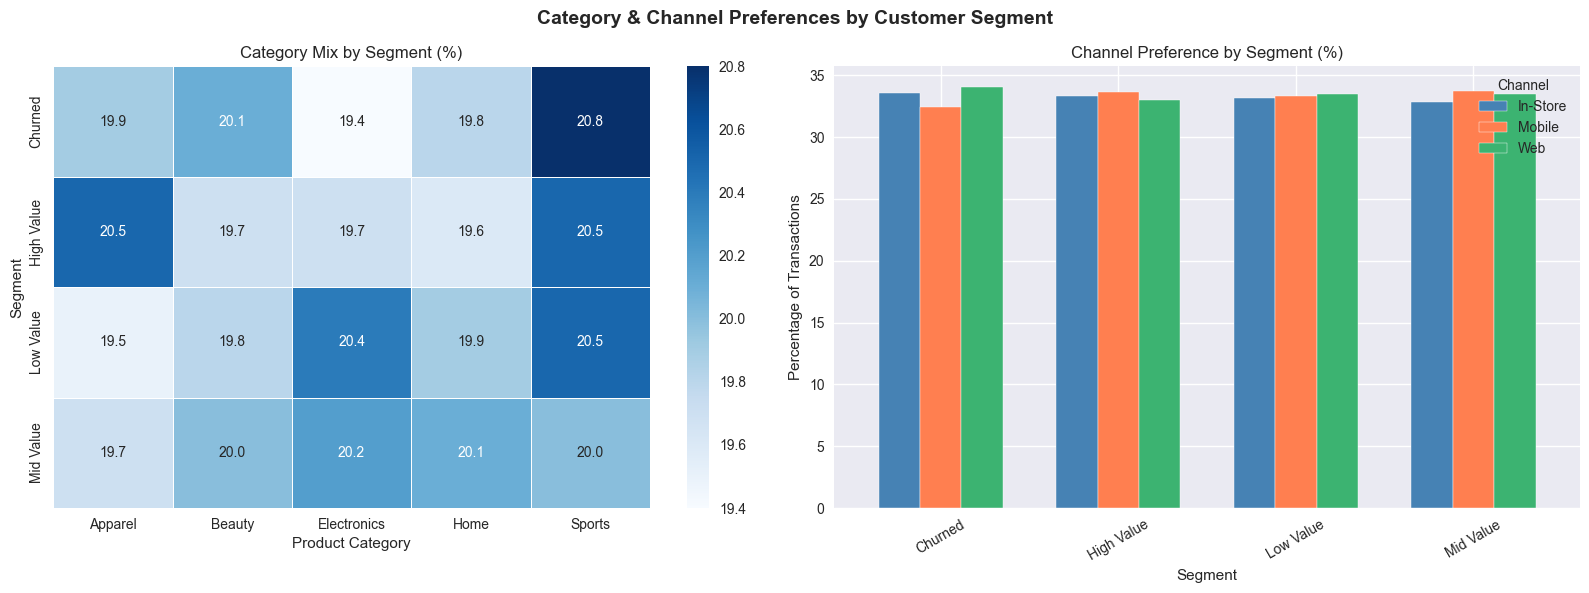

Chart saved to outputs/category_channel.png


In [39]:
def category_channel_analysis(df_clean, rfm_clustered):
    
    # Merge cluster labels back to transaction level
    txn_with_clusters = df_clean.merge(
        rfm_clustered[["customer_id", "cluster_label"]],
        on="customer_id",
        how="left"
    )
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(
        "Category & Channel Preferences by Customer Segment",
        fontsize=14, fontweight="bold"
    )
    
    # Plot 1 — Category heatmap by segment
    cat_segment = pd.crosstab(
        txn_with_clusters["cluster_label"],
        txn_with_clusters["product_category"],
        normalize="index"
    ) * 100
    
    sns.heatmap(
        cat_segment.round(1),
        annot=True,
        fmt=".1f",
        cmap="Blues",
        ax=axes[0],
        linewidths=0.5
    )
    axes[0].set_title("Category Mix by Segment (%)")
    axes[0].set_xlabel("Product Category")
    axes[0].set_ylabel("Segment")
    
    # Plot 2 — Channel preference by segment
    channel_segment = pd.crosstab(
        txn_with_clusters["cluster_label"],
        txn_with_clusters["channel"],
        normalize="index"
    ) * 100
    
    channel_segment.plot(
        kind="bar",
        ax=axes[1],
        color=["steelblue", "coral", "mediumseagreen"],
        edgecolor="white",
        width=0.7
    )
    axes[1].set_title("Channel Preference by Segment (%)")
    axes[1].set_xlabel("Segment")
    axes[1].set_ylabel("Percentage of Transactions")
    axes[1].legend(title="Channel")
    axes[1].tick_params(axis="x", rotation=30)
    
    plt.tight_layout()
    plt.savefig("outputs/category_channel.png",
                dpi=150, bbox_inches="tight")
    plt.show()
    print("Chart saved to outputs/category_channel.png")


category_channel_analysis(df_clean, rfm_clustered)

### 6.4 — Export Results for Power BI Dashboard

In [41]:
def export_results(rfm_clustered, df_clean, merged):
    
    # Export 1 — Full RFM results
    rfm_export = rfm_clustered[[
        "customer_id", "recency", "frequency", "monetary",
        "r_score", "f_score", "m_score", "rfm_total",
        "rfm_score", "segment", "cluster", "cluster_label"
    ]]
    rfm_export.to_csv(
        "outputs/rfm_scores.csv", index=False
    )
    print(f"Exported rfm_scores.csv "
          f"— {len(rfm_export):,} rows")
    
    # Export 2 — Cluster summary
    cluster_exp = rfm_clustered.groupby("cluster_label").agg(
        customer_count = ("customer_id",  "count"),
        total_revenue  = ("monetary",     "sum"),
        avg_spend      = ("monetary",     "mean"),
        avg_frequency  = ("frequency",    "mean"),
        avg_recency    = ("recency",      "mean")
    ).round(2).reset_index()
    cluster_exp.to_csv(
        "outputs/cluster_summary.csv", index=False
    )
    print(f"Exported cluster_summary.csv "
          f"— {len(cluster_exp):,} rows")
    
    # Export 3 — Transactions with cluster labels
    txn_export = df_clean.merge(
        rfm_clustered[["customer_id", "cluster_label", 
                       "segment", "rfm_total"]],
        on="customer_id",
        how="left"
    )
    txn_export.to_csv(
        "outputs/transactions_labelled.csv", index=False
    )
    print(f"Exported transactions_labelled.csv "
          f"— {len(txn_export):,} rows")
    
    # Export 4 — Validation results
    merged[[
        "customer_id", "true_tier", 
        "cluster_label", "correct"
    ]].to_csv("outputs/validation_results.csv", index=False)
    print(f"Exported validation_results.csv "
          f"— {len(merged):,} rows")
    
    print("\nAll files exported to outputs/ folder")
    print("Ready for Power BI dashboard")


export_results(rfm_clustered, df_clean, merged)

Exported rfm_scores.csv — 7,546 rows
Exported cluster_summary.csv — 4 rows
Exported transactions_labelled.csv — 54,177 rows
Exported validation_results.csv — 7,546 rows

All files exported to outputs/ folder
Ready for Power BI dashboard


## Section 7 — Executive Summary

### Project Overview
Analysis of 55,000 retail transactions across 8,000 customers
using RFM scoring and K-Means clustering to identify
actionable customer segments.

---

### Key Findings

#### Revenue Concentration
| Segment | Customers | Revenue Share |
|---|---|---|
| High Value | 750 (9.9%) | £4,346,016 (56.8%) |
| Mid Value | 1,814 (24.0%) | £2,303,999 (30.1%) |
| Low Value | 3,332 (44.2%) | £889,600 (11.6%) |
| Churned | 1,650 (21.9%) | £107,419 (1.4%) |

**Classic Pareto pattern — top 10% of customers 
drive 57% of revenue.**

---

#### Model Performance
| Metric | Score |
|---|---|
| Adjusted Rand Index | 0.72 (Strong) |
| Overall Accuracy | 89.3% |
| Churned Detection | 100% |
| High Value Detection | 89.4% |

---

#### Business Recommendations

**1. Protect High Value Customers (750 customers)**
- Avg spend £5,795 | Shopping every 3 days
- Immediate priority: loyalty programme, dedicated account manager
- Risk: losing one high value customer =<span class="ml-2" /><span class="inline-block w-3 h-3 rounded-full bg-neutral-a12 align-middle mb-[0.1rem]" />

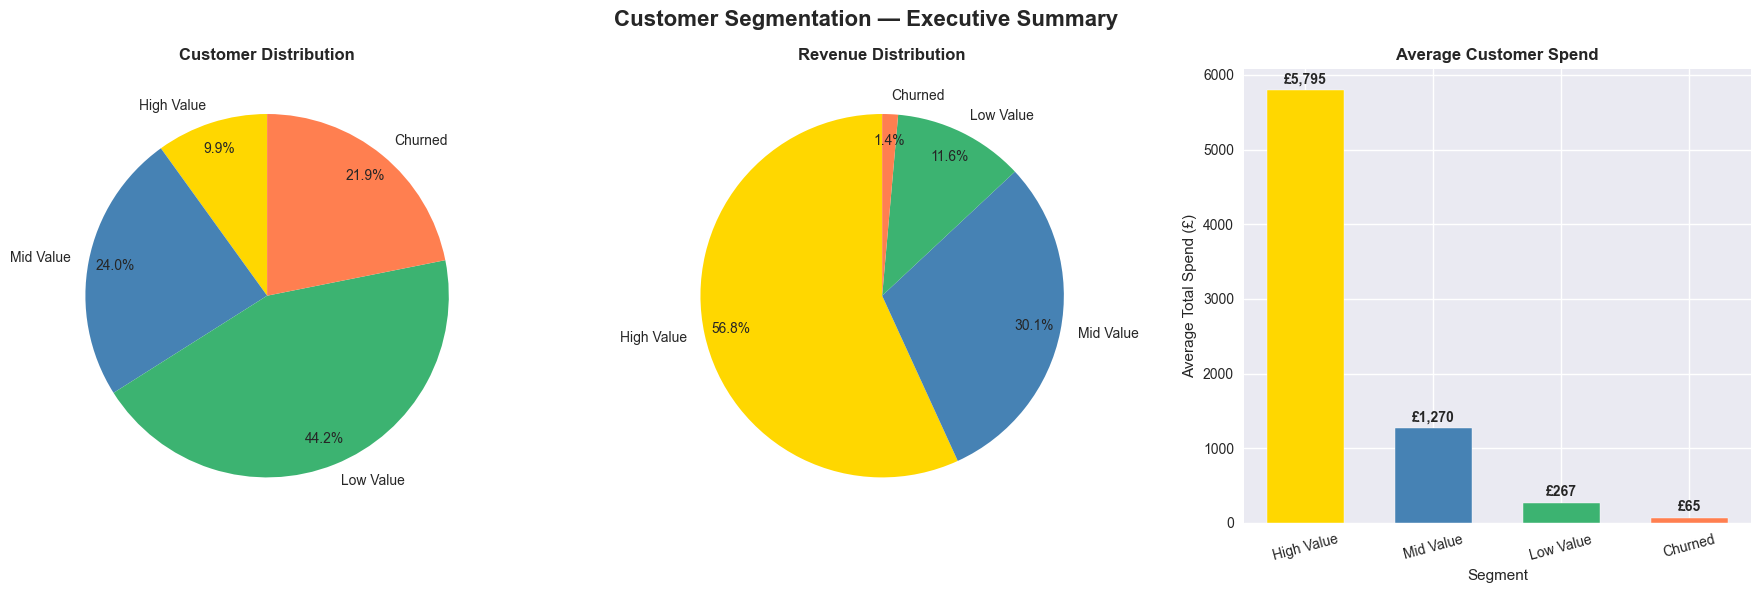

Chart saved to outputs/executive_summary.png


In [42]:
def final_summary_chart(rfm_clustered):
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle(
        "Customer Segmentation — Executive Summary",
        fontsize=16, fontweight="bold"
    )
    
    colors = {
        "High Value" : "gold",
        "Mid Value"  : "steelblue",
        "Low Value"  : "mediumseagreen",
        "Churned"    : "coral"
    }
    color_list = [colors[l] for l in 
                  ["High Value", "Mid Value", 
                   "Low Value", "Churned"]]
    
    # Plot 1 — Customer share pie
    customer_counts = rfm_clustered[
        "cluster_label"
    ].value_counts().reindex(
        ["High Value", "Mid Value", "Low Value", "Churned"]
    )
    
    axes[0].pie(
        customer_counts.values,
        labels=customer_counts.index,
        colors=color_list,
        autopct="%1.1f%%",
        startangle=90,
        pctdistance=0.85
    )
    axes[0].set_title("Customer Distribution", 
                      fontweight="bold")
    
    # Plot 2 — Revenue share pie
    revenue_by_segment = rfm_clustered.groupby(
        "cluster_label"
    )["monetary"].sum().reindex(
        ["High Value", "Mid Value", "Low Value", "Churned"]
    )
    
    axes[1].pie(
        revenue_by_segment.values,
        labels=revenue_by_segment.index,
        colors=color_list,
        autopct="%1.1f%%",
        startangle=90,
        pctdistance=0.85
    )
    axes[1].set_title("Revenue Distribution",
                      fontweight="bold")
    
    # Plot 3 — Average spend bar chart
    avg_spend = rfm_clustered.groupby(
        "cluster_label"
    )["monetary"].mean().reindex(
        ["High Value", "Mid Value", "Low Value", "Churned"]
    )
    
    bars = axes[2].bar(
        avg_spend.index,
        avg_spend.values,
        color=color_list,
        edgecolor="white",
        width=0.6
    )
    
    # Add value labels on bars
    for bar, val in zip(bars, avg_spend.values):
        axes[2].text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 50,
            f"£{val:,.0f}",
            ha="center",
            va="bottom",
            fontweight="bold",
            fontsize=10
        )
    
    axes[2].set_title("Average Customer Spend",
                      fontweight="bold")
    axes[2].set_xlabel("Segment")
    axes[2].set_ylabel("Average Total Spend (£)")
    axes[2].tick_params(axis="x", rotation=15)
    
    plt.tight_layout()
    plt.savefig("outputs/executive_summary.png",
                dpi=150, bbox_inches="tight")
    plt.show()
    print("Chart saved to outputs/executive_summary.png")


final_summary_chart(rfm_clustered)